**Title :**
Sales Forecasting using Machine Learning

**Introduction :**
This project aims to predict future sales using historical data. By analysing past sales trends , we build machine learning models to forecast future demand and help bussiness make better decisions.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
df=pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [66]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Data Preprocessing : The dataset was checked for missing values and duplicates. No missing or duplicate values were found, ensuring clean data for modeling

In [67]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [68]:
df.duplicated().sum()

np.int64(0)

##Feature Engineering

Date column was converted into Year and Month features.
This helps the model understand time-based patterns in sales.

In [69]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month

In [70]:
monthly_sales=df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales.head()

,Year,Month,Sales
0,2014,1,14236.895
1,2014,2,4519.892
2,2014,3,55691.009
3,2014,4,28295.345
4,2014,5,23648.287


In [71]:
x=monthly_sales[['Year','Month']]
y=monthly_sales['Sales']

## Model Building

Two models were used:
- Linear Regression
- Random Forest Regressor

These models were trained to predict sales based on time features.

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)

LinearRegression()

In [73]:
lr_pred=model.predict(x_test)

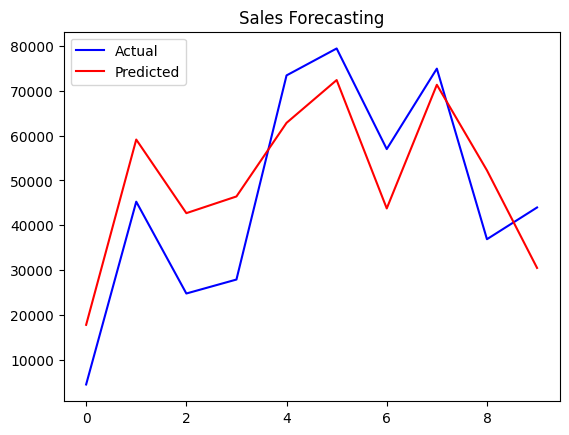

In [74]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(y_test.values,color='blue',label='Actual')
plt.plot(lr_pred,color='red',label='Predicted')
plt.legend()
plt.title("Sales Forecasting")
plt.show()

In [75]:
from sklearn.metrics import mean_absolute_percentage_error
lr_mae=mean_absolute_percentage_error(y_test,lr_pred)
print("Mean Absolute Error percentage:",lr_mae)

Mean Absolute Error percentage: 0.5868033753909401


In [76]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor()
rf_model.fit(x_train,y_train)

RandomForestRegressor()

In [77]:
rf_pred=rf_model.predict(x_test)

## Model Evaluation

The performance of models was evaluated using error metric  MAPE.
Linear Regression performed better compared to Random Forest in this case.

In [78]:
from sklearn.metrics import mean_absolute_percentage_error
print("Linear regression MAE Percentage:",mean_absolute_percentage_error(y_test,lr_pred))
print("Random Forest MAE Percentage:",mean_absolute_percentage_error(y_test,rf_pred))


Linear regression MAE Percentage: 0.5868033753909401
Random Forest MAE Percentage: 0.43088119346419507


## Visualization

Various plots were created to compare actual vs predicted sales,
analyze monthly trends, and understand seasonal patterns.

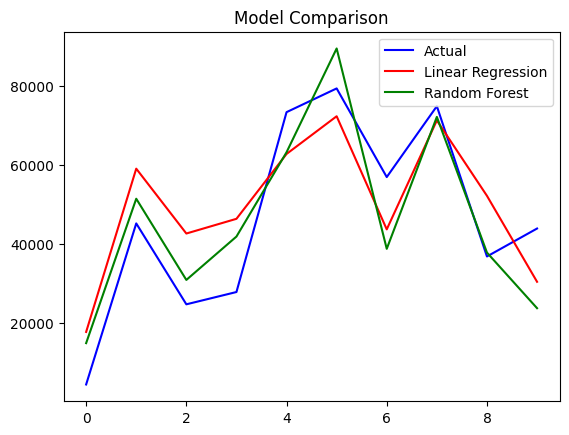

In [79]:
plt.figure()
plt.plot(y_test.values,color='blue',label='Actual')
plt.plot(lr_pred,color='red',label='Linear Regression')
plt.plot(rf_pred,color='green',label='Random Forest')
plt.legend()
plt.title("Model Comparison")
plt.show()

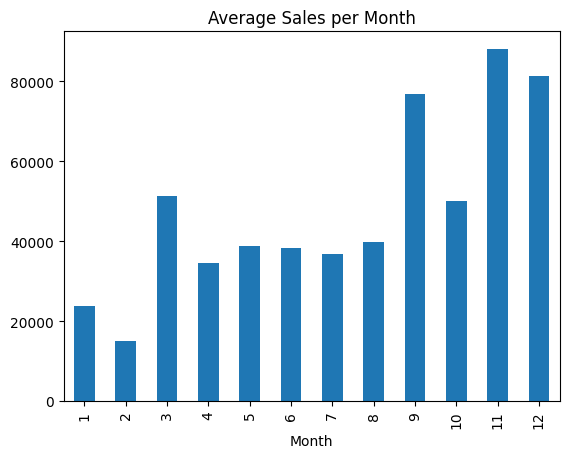

In [80]:
monthly_sales.groupby('Month')['Sales'].mean().plot(kind='bar')
plt.title("Average Sales per Month")
plt.show()

In [81]:
print(monthly_sales.sort_values(by='Sales',ascending=False).head())

    Year  Month        Sales
46  2017     11  118447.8250
35  2016     12   96999.0430
44  2017      9   87866.6520
47  2017     12   83829.3188
8   2014      9   81777.3508


## Future Sales Prediction

The model was used to predict sales for the next 6 months.
This helps businesses plan ahead based on expected demand.

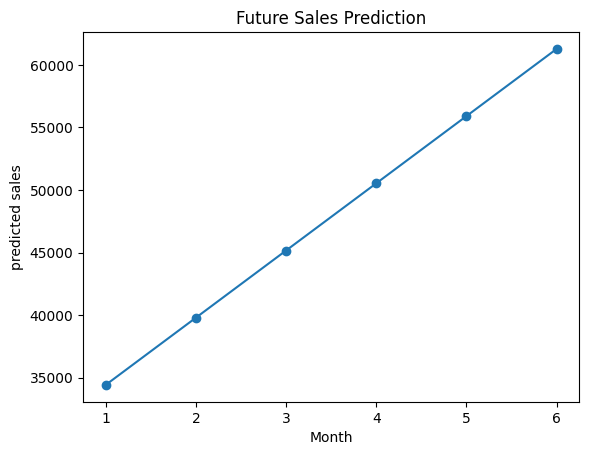

In [82]:
future=pd.DataFrame({'Year':[2018]*6,'Month':[1,2,3,4,5,6]})
future_pred=lr_model.predict(future)
plt.figure()
plt.plot(range(1,7),future_pred,marker='o')
plt.title("Future Sales Prediction")
plt.xlabel("Month")
plt.ylabel("predicted sales")
plt.show()

## Business Insights

The model predicts future sales based on past trends.

- Sales show seasonal patterns across months
- Higher sales observed in later months (festive season)
- Lower sales at the beginning of the year

Businesses can use this forecast to:
- Plan inventory efficiently
- Avoid overstocking or shortages
- Schedule marketing campaigns
- Improve decision-making

The model shows a gradual increasing trend due to limited features.
Including more features like region or category can improve accuracy.

## Conclusion

This project demonstrates how machine learning can be used to forecast sales.
Linear Regression provided better results in this case.

The model can help businesses make data-driven decisions and improve planning strategies.